### **Data Loading**

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [2]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import csr_matrix

In [4]:
# Loading datasets
ratings = pd.read_csv('rating.csv')
movies = pd.read_csv('movie.csv')
tags = pd.read_csv('tag.csv')
links = pd.read_csv('link.csv')
genome_scores = pd.read_csv('genome_scores.csv')
genome_tags = pd.read_csv('genome_tags.csv')

### **Displaying datasets information**

In [5]:
# Movie dataset
print("Movies Data:")
print(movies.head())
print(f"\nMovies shape: {movies.shape}")
print(f"\nMovies columns: {movies.columns}")

print("\nMovies info:")
print(movies.info())
print("\nMovies distribution:")
print(movies.describe())


Movies Data:
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  

Movies shape: (27278, 3)

Movies columns: Index(['movieId', 'title', 'genres'], dtype='object')

Movies info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27278 entries, 0 to 27277
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  27278 non-null  int64 
 1   title    27278 non-null  object
 2   genres   27278 non-n

In [6]:
# Ratings dataset
print("Rating Data:")
print(ratings.head())
print(f"\nRatings shape: {ratings.shape}")
print(f"\nRatings columns: {ratings.columns}")

print("\nRatings info:")
print(ratings.info())
print("\nRatings distribution:")
print(ratings.describe())


Rating Data:
   userId  movieId  rating            timestamp
0       1        2     3.5  2005-04-02 23:53:47
1       1       29     3.5  2005-04-02 23:31:16
2       1       32     3.5  2005-04-02 23:33:39
3       1       47     3.5  2005-04-02 23:32:07
4       1       50     3.5  2005-04-02 23:29:40

Ratings shape: (319682, 4)

Ratings columns: Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='object')

Ratings info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319682 entries, 0 to 319681
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     319682 non-null  int64  
 1   movieId    319682 non-null  int64  
 2   rating     319682 non-null  float64
 3   timestamp  319681 non-null  object 
dtypes: float64(1), int64(2), object(1)
memory usage: 9.8+ MB
None

Ratings distribution:
              userId        movieId         rating
count  319682.000000  319682.000000  319682.000000
mean     1100.021596  

In [7]:
# Tags dataset
print("Tags Data:")
print(tags.head())
print(f"\nTags shape: {tags.shape}")
print(f"\nTags columns: {tags.columns}")

print("\nTags info:")
print(tags.info())
print("\nTags distribution:")
print(tags.describe())


Tags Data:
   userId  movieId            tag            timestamp
0      18     4141    Mark Waters  2009-04-24 18:19:40
1      65      208      dark hero  2013-05-10 01:41:18
2      65      353      dark hero  2013-05-10 01:41:19
3      65      521  noir thriller  2013-05-10 01:39:43
4      65      592      dark hero  2013-05-10 01:41:18

Tags shape: (405473, 4)

Tags columns: Index(['userId', 'movieId', 'tag', 'timestamp'], dtype='object')

Tags info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 405473 entries, 0 to 405472
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   userId     405473 non-null  int64 
 1   movieId    405473 non-null  int64 
 2   tag        405458 non-null  object
 3   timestamp  405473 non-null  object
dtypes: int64(2), object(2)
memory usage: 12.4+ MB
None

Tags distribution:
              userId        movieId
count  405473.000000  405473.000000
mean    59618.279829   32806.900985
std     

In [8]:
# Links dataset
print("Links Data:")
print(links.head())
print(f"\nLinks shape: {links.shape}")
print(f"\nLinks columns: {links.columns}")

print("\nLinks info:")
print(links.info())
print("\nLinks distribution:")
print(links.describe())


Links Data:
   movieId  imdbId   tmdbId
0        1  114709    862.0
1        2  113497   8844.0
2        3  113228  15602.0
3        4  114885  31357.0
4        5  113041  11862.0

Links shape: (27278, 3)

Links columns: Index(['movieId', 'imdbId', 'tmdbId'], dtype='object')

Links info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27278 entries, 0 to 27277
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   movieId  27278 non-null  int64  
 1   imdbId   27278 non-null  int64  
 2   tmdbId   27026 non-null  float64
dtypes: float64(1), int64(2)
memory usage: 639.5 KB
None

Links distribution:
             movieId        imdbId         tmdbId
count   27278.000000  2.727800e+04   27026.000000
mean    59855.480570  5.781860e+05   63846.683083
std     44429.314697  7.804707e+05   69862.134497
min         1.000000  5.000000e+00       2.000000
25%      6931.250000  7.741725e+04   15936.500000
50%     68068.000000  1.524350e+05 

In [9]:
# Genome_Tags dataset
print("Genome_Tags Data:")
print(genome_tags.head())
print(f"\nGenome_Tags shape: {genome_tags.shape}")
print(f"\nGenome_Tags columns: {genome_tags.columns}")

print("\nGenome_Tags info:")
print(genome_tags.info())
print("\nGenome_Tags distribution:")
print(genome_tags.describe())


Genome_Tags Data:
   tagId           tag
0      1           007
1      2  007 (series)
2      3  18th century
3      4         1920s
4      5         1930s

Genome_Tags shape: (1128, 2)

Genome_Tags columns: Index(['tagId', 'tag'], dtype='object')

Genome_Tags info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1128 entries, 0 to 1127
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   tagId   1128 non-null   int64 
 1   tag     1128 non-null   object
dtypes: int64(1), object(1)
memory usage: 17.8+ KB
None

Genome_Tags distribution:
             tagId
count  1128.000000
mean    564.500000
std     325.769857
min       1.000000
25%     282.750000
50%     564.500000
75%     846.250000
max    1128.000000


In [10]:
# Genome_Scores dataset
print("Genome_Scores Data:")
print(genome_scores.head())
print(f"\Genome_Scores shape: {genome_scores.shape}")
print(f"\Genome_Scores columns: {genome_scores.columns}")

print("\Genome_Scores info:")
print(genome_scores.info())
print("\Genome_Scores distribution:")
print(genome_scores.describe())


Genome_Scores Data:
   movieId  tagId  relevance
0        1    1.0    0.02500
1        1    2.0    0.02500
2        1    3.0    0.05775
3        1    4.0    0.09675
4        1    5.0    0.14675
\Genome_Scores shape: (2279841, 3)
\Genome_Scores columns: Index(['movieId', 'tagId', 'relevance'], dtype='object')
\Genome_Scores info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2279841 entries, 0 to 2279840
Data columns (total 3 columns):
 #   Column     Dtype  
---  ------     -----  
 0   movieId    int64  
 1   tagId      float64
 2   relevance  float64
dtypes: float64(2), int64(1)
memory usage: 52.2 MB
None
\Genome_Scores distribution:
            movieId         tagId     relevance
count  2.279841e+06  2.279840e+06  2.279840e+06
mean   1.140121e+03  5.644675e+02  1.138497e-01
std    6.775789e+02  3.256392e+02  1.512380e-01
min    1.000000e+00  1.000000e+00  2.500000e-04
25%    5.310000e+02  2.820000e+02  2.450000e-02
50%    1.129000e+03  5.640000e+02  5.600000e-02
75%    1.731000e

### **Data Preprocessing**

In [11]:
# Check timestamp format
print("\nTimestamp sample:")
print(ratings['timestamp'].head())


Timestamp sample:
0    2005-04-02 23:53:47
1    2005-04-02 23:31:16
2    2005-04-02 23:33:39
3    2005-04-02 23:32:07
4    2005-04-02 23:29:40
Name: timestamp, dtype: object


In [12]:
# Convert timestamp to datetime - FIXED VERSION
try:
    # First try converting as Unix timestamp
    ratings['timestamp'] = pd.to_datetime(ratings['timestamp'], unit='s')
except (ValueError, TypeError):
    try:
        # If that fails, try converting as string
        ratings['timestamp'] = pd.to_datetime(ratings['timestamp'])
    except:
        # If all fails, drop the column
        ratings = ratings.drop('timestamp', axis=1)
        print("Could not convert timestamp, dropping column")

In [13]:
# Merging movies with ratings
movie_ratings = pd.merge(ratings, movies, on='movieId')
print("\nMerged Ratings with Movies:")
print(movie_ratings.head())


Merged Ratings with Movies:
   userId  movieId  rating           timestamp  \
0       1        2     3.5 2005-04-02 23:53:47   
1       1       29     3.5 2005-04-02 23:31:16   
2       1       32     3.5 2005-04-02 23:33:39   
3       1       47     3.5 2005-04-02 23:32:07   
4       1       50     3.5 2005-04-02 23:29:40   

                                               title  \
0                                     Jumanji (1995)   
1  City of Lost Children, The (Cité des enfants p...   
2          Twelve Monkeys (a.k.a. 12 Monkeys) (1995)   
3                        Seven (a.k.a. Se7en) (1995)   
4                         Usual Suspects, The (1995)   

                                   genres  
0              Adventure|Children|Fantasy  
1  Adventure|Drama|Fantasy|Mystery|Sci-Fi  
2                 Mystery|Sci-Fi|Thriller  
3                        Mystery|Thriller  
4                  Crime|Mystery|Thriller  


In [14]:
# Handling missing values
print("\nMissing values before cleaning:")
print(movie_ratings.isnull().sum())


Missing values before cleaning:
userId       0
movieId      0
rating       0
timestamp    1
title        0
genres       0
dtype: int64


In [15]:
# Dropping rows with missing values
movie_ratings = movie_ratings.dropna()
print("\nMissing values after cleaning:", movie_ratings.isnull().sum().sum())


Missing values after cleaning: 0


In [16]:
# Filter data to reduce size
min_user_ratings = 20
min_movie_ratings = 20
filtered_users = movie_ratings['userId'].value_counts()
filtered_users = filtered_users[filtered_users >= min_user_ratings].index.tolist()
filtered_movies = movie_ratings['movieId'].value_counts()
filtered_movies = filtered_movies[filtered_movies >= min_movie_ratings].index.tolist()

filtered_ratings = movie_ratings[
    (movie_ratings['userId'].isin(filtered_users)) &
    (movie_ratings['movieId'].isin(filtered_movies))
]
print(f"\nFiltered data shape: {filtered_ratings.shape}")



Filtered data shape: (279702, 6)


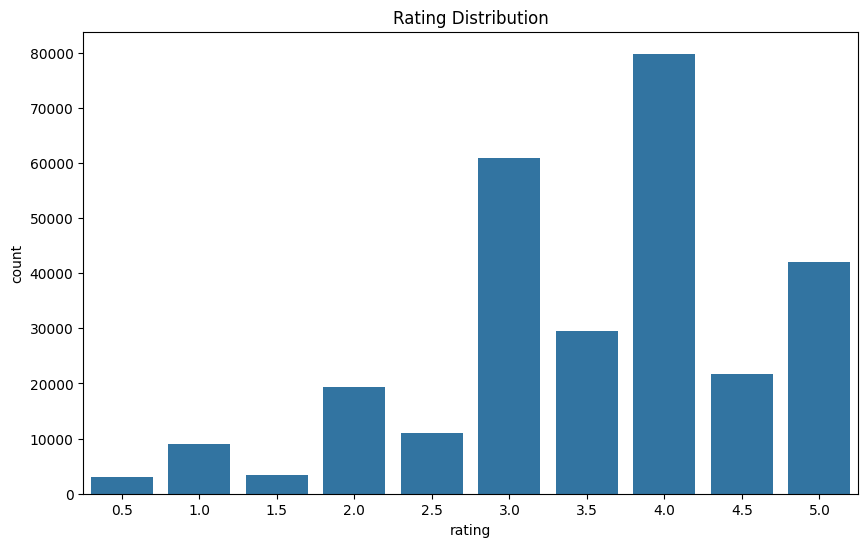

In [18]:
# Exploratory Data Analysis
plt.figure(figsize=(10, 6))
sns.countplot(x='rating', data=filtered_ratings)
plt.title('Rating Distribution')
plt.show()

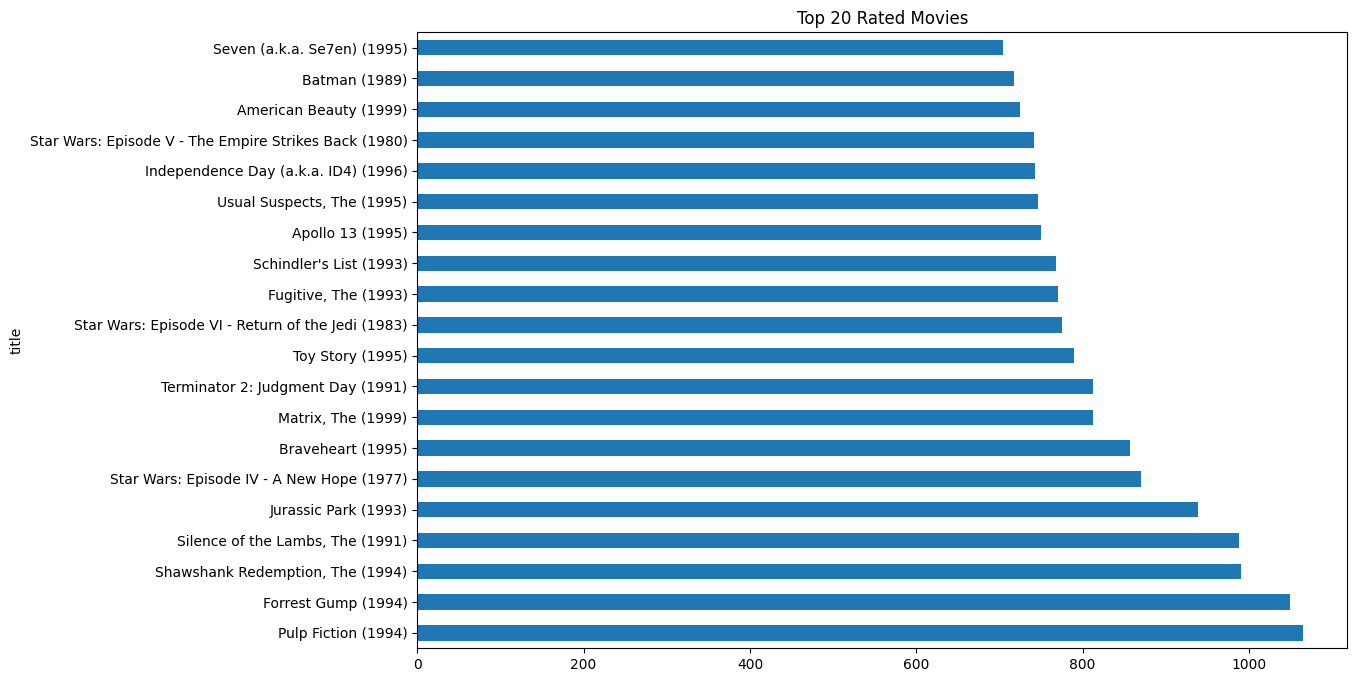

In [19]:
plt.figure(figsize=(12, 8))
top_movies = filtered_ratings['title'].value_counts()[:20]
top_movies.plot(kind='barh')
plt.title('Top 20 Rated Movies')
plt.show()

In [20]:
# Creating sparse user-item matrix
user_item_matrix = filtered_ratings.pivot_table(
    index='userId',
    columns='movieId',
    values='rating',
    fill_value=0
)
print("\nUser-Item Matrix Shape:", user_item_matrix.shape)


User-Item Matrix Shape: (2184, 2831)


In [21]:
# Convert to sparse matrix for efficiency
sparse_user_item = csr_matrix(user_item_matrix.values)

#### **# Phase 1: Item-Based Collaborative Filtering**


In [24]:
def item_based_recommendations(movie_id, n=5):
    """Get similar movies based on item-item cosine similarity"""
    # Calculate item-item similarity
    item_similarity = cosine_similarity(user_item_matrix.T)

    # Create similarity dataframe
    item_sim_df = pd.DataFrame(
        item_similarity,
        index=user_item_matrix.columns,
        columns=user_item_matrix.columns
    )

    # Find similar items
    similar_items = item_sim_df[movie_id].sort_values(ascending=False)[1:n+1]

    # Get movie titles
    similar_movies = movies[movies['movieId'].isin(similar_items.index)]
    similar_movies['similarity_score'] = similar_movies['movieId'].map(similar_items)

    return similar_movies[['movieId', 'title', 'genres', 'similarity_score']]


In [25]:
# Test item-based CF
toy_story_id = movies[movies['title'].str.contains('Toy Story')]['movieId'].values[0]
print(f"\nItem-Based Recommendations for 'Toy Story':")
print(item_based_recommendations(toy_story_id))


Item-Based Recommendations for 'Toy Story':
      movieId                                              title  \
257       260          Star Wars: Episode IV - A New Hope (1977)   
767       780               Independence Day (a.k.a. ID4) (1996)   
1184     1210  Star Wars: Episode VI - Return of the Jedi (1983)   
1242     1270                          Back to the Future (1985)   
3027     3114                                 Toy Story 2 (1999)   

                                           genres  similarity_score  
257                       Action|Adventure|Sci-Fi          0.568594  
767              Action|Adventure|Sci-Fi|Thriller          0.555715  
1184                      Action|Adventure|Sci-Fi          0.549676  
1242                      Adventure|Comedy|Sci-Fi          0.554172  
3027  Adventure|Animation|Children|Comedy|Fantasy          0.550695  


/tmp/ipython-input-24-1780791019.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  similar_movies['similarity_score'] = similar_movies['movieId'].map(similar_items)


#### **# Phase 2: Matrix Factorization using Truncated SVD**

In [26]:
# Train-test split
train_df, test_df = train_test_split(filtered_ratings, test_size=0.25, random_state=42)

In [27]:
# Create train user-item matrix
train_matrix = train_df.pivot_table(
    index='userId',
    columns='movieId',
    values='rating',
    fill_value=0
)

In [28]:
# Align with full matrix columns
train_matrix = train_matrix.reindex(columns=user_item_matrix.columns, fill_value=0)

In [29]:
# Convert to sparse matrix
sparse_train = csr_matrix(train_matrix.values)

In [30]:
# Performing matrix factorization
n_components = 20  # Number of latent factors
svd = TruncatedSVD(n_components=n_components, random_state=42)
user_factors = svd.fit_transform(sparse_train)
item_factors = svd.components_.T

In [31]:
# Reconstruct the matrix
reconstructed_matrix = user_factors @ item_factors.T

In [32]:
# Create reconstructed DataFrame
reconstructed_df = pd.DataFrame(
    reconstructed_matrix,
    index=train_matrix.index,
    columns=train_matrix.columns
)

In [33]:
# Function to predict rating
def predict_rating(user_id, movie_id):
    try:
        user_idx = train_matrix.index.get_loc(user_id)
        movie_idx = train_matrix.columns.get_loc(movie_id)
        return reconstructed_df.iloc[user_idx, movie_idx]
    except KeyError:
        # If user or movie not in train, return average rating
        return filtered_ratings['rating'].mean()


In [34]:
# Evaluate on test set
test_df['predicted'] = test_df.apply(
    lambda row: predict_rating(row['userId'], row['movieId']),
    axis=1
)

In [35]:
# Calculate RMSE
rmse = np.sqrt(mean_squared_error(test_df['rating'], test_df['predicted']))
print(f"\nMatrix Factorization RMSE: {rmse:.4f}")


Matrix Factorization RMSE: 2.8177


#### **Phase 3: Generating Recommendations**

In [36]:
def get_user_recommendations(user_id, n=5):
    """Get top recommendations for a user"""
    # Check if user is in training set
    if user_id not in train_matrix.index:
        # If new user, recommend popular movies
        return movies.sort_values(by='movieId', key=lambda x: x.map(
            filtered_ratings['movieId'].value_counts()
        ), ascending=False).head(n)

    # Get user index
    user_idx = train_matrix.index.get_loc(user_id)

    # Get predicted ratings for all movies
    predicted_ratings = reconstructed_df.iloc[user_idx]

    # Get movies user hasn't rated
    rated_movies = set(filtered_ratings[filtered_ratings['userId'] == user_id]['movieId'])
    unrated_movies = [mid for mid in train_matrix.columns if mid not in rated_movies]

    # Get top predictions
    top_movie_ids = predicted_ratings[unrated_movies].sort_values(ascending=False).head(n).index

    # Get movie details
    recommendations = movies[movies['movieId'].isin(top_movie_ids)]
    recommendations['predicted_rating'] = recommendations['movieId'].map(predicted_ratings)

    return recommendations.sort_values('predicted_rating', ascending=False)


In [37]:
# Test recommendation function
user_id = 1
print(f"\nTop 5 Recommendations for User {user_id}:")
print(get_user_recommendations(user_id))


Top 5 Recommendations for User 1:
      movieId                       title  \
6764     6874    Kill Bill: Vol. 1 (2003)   
1242     1270   Back to the Future (1985)   
1180     1206  Clockwork Orange, A (1971)   
1172     1197  Princess Bride, The (1987)   
2486     2571          Matrix, The (1999)   

                                       genres  predicted_rating  
6764                    Action|Crime|Thriller          1.912224  
1242                  Adventure|Comedy|Sci-Fi          1.838868  
1180              Crime|Drama|Sci-Fi|Thriller          1.827339  
1172  Action|Adventure|Comedy|Fantasy|Romance          1.813088  
2486                   Action|Sci-Fi|Thriller          1.781911  


/tmp/ipython-input-36-2095665677.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  recommendations['predicted_rating'] = recommendations['movieId'].map(predicted_ratings)


In [38]:
# Find similar users
def get_similar_users(user_id, n=5):
    """Find users with similar preferences"""
    if user_id not in train_matrix.index:
        return []

    # Find user index
    user_idx = train_matrix.index.get_loc(user_id)

    # Find similar users using cosine similarity
    user_similarity = cosine_similarity([user_factors[user_idx]], user_factors)[0]

    # Get top similar users (excluding self)
    similar_user_indices = np.argsort(user_similarity)[::-1][1:n+1]
    similar_users = train_matrix.index[similar_user_indices]

    return similar_users.tolist()

print(f"\nUsers similar to User {user_id}: {get_similar_users(user_id)}")



Users similar to User 1: [77, 1839, 364, 995, 147]


#### **Phase 4: Hybrid Recommendation**

In [39]:
def hybrid_recommendation(user_id, movie_id):
    """Combine collaborative filtering with content-based features"""
    # Collaborative filtering prediction
    collab_score = predict_rating(user_id, movie_id)

    # Content-based component (using tags)
    try:
        # Get tag relevance scores
        movie_tags = genome_scores[genome_scores['movieId'] == movie_id]
        if not movie_tags.empty:
            avg_tag_score = movie_tags['relevance'].mean()
            # Weighted average (70% collaborative, 30% content)
            return 0.7 * collab_score + 0.3 * avg_tag_score
    except:
        pass

    return collab_score


In [40]:
# Test hybrid recommendation
inception_id = movies[movies['title'].str.contains('Inception')]['movieId'].values[0]
print(f"\nHybrid score for User {user_id}, Movie 'Inception': {hybrid_recommendation(user_id, inception_id):.2f}")



Hybrid score for User 1, Movie 'Inception': 0.21


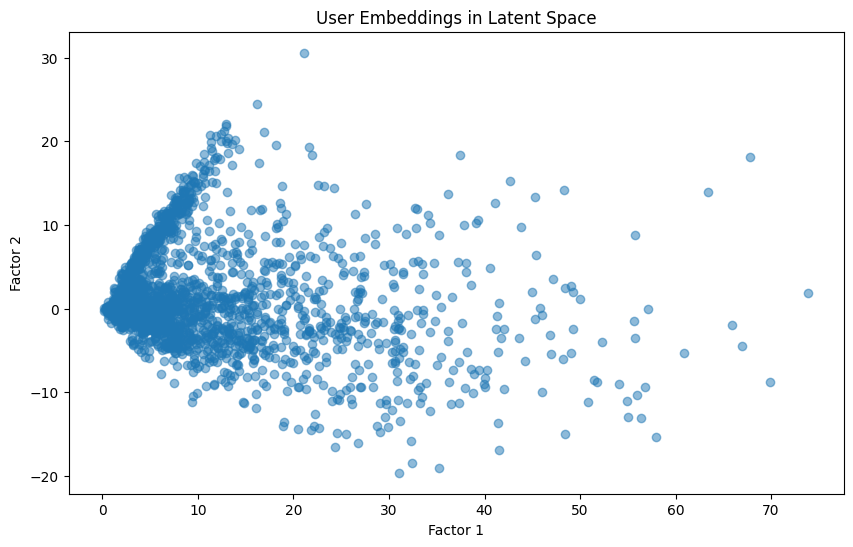

In [41]:
# Visualization of latent factors
plt.figure(figsize=(10, 6))
plt.scatter(user_factors[:, 0], user_factors[:, 1], alpha=0.5)
plt.title('User Embeddings in Latent Space')
plt.xlabel('Factor 1')
plt.ylabel('Factor 2')
plt.show()

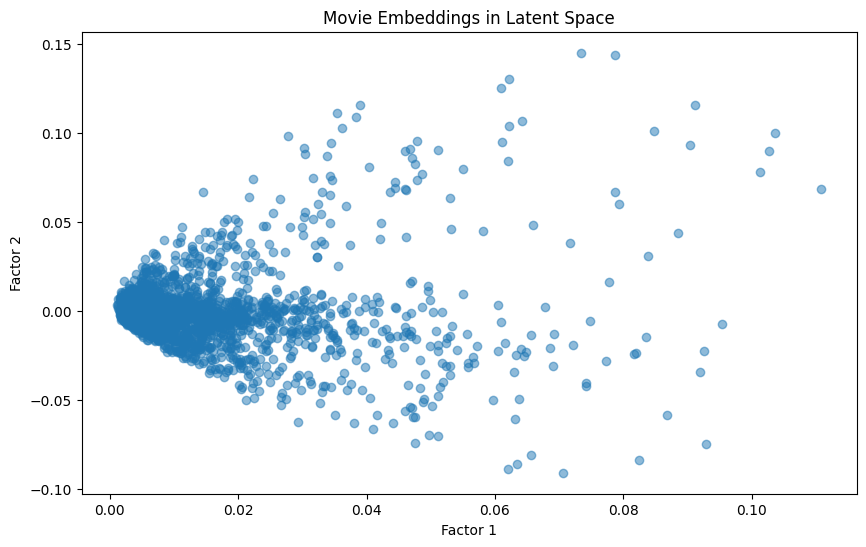

In [42]:
plt.figure(figsize=(10, 6))
plt.scatter(item_factors[:, 0], item_factors[:, 1], alpha=0.5)
plt.title('Movie Embeddings in Latent Space')
plt.xlabel('Factor 1')
plt.ylabel('Factor 2')
plt.show()

In [43]:
# Save recommendations to file
user_recommendations = get_user_recommendations(user_id)
user_recommendations.to_csv(f'user_{user_id}_recommendations.csv', index=False)
print(f"\nSaved recommendations for user {user_id} to CSV file")

print("\nRecommender system implementation complete!")


Saved recommendations for user 1 to CSV file

Recommender system implementation complete!


/tmp/ipython-input-36-2095665677.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  recommendations['predicted_rating'] = recommendations['movieId'].map(predicted_ratings)
